In [5]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ["PYTHONUTF8"] = "1"
sys.path.append(os.path.abspath(".."))

from src.ssm_models import LocalLinearTrendSeasonalWithMultiFixedExog
from src.data_loader import load_transport_data
from src.features import prepare_event_data

DATA_PATH = '../data/Transport_amount_data.csv'

#　イベント定義
custom_events = {
    'hike_dummy':  ('2017-10-01', '2019-12-31'),
    'covid_main':  ('2020-03-01', None),
    'covid_wave1': ('2020-04-01', '2020-05-31'),
    'covid_2021':  ('2021-01-01', '2021-09-30'),
    #'shock_dummy': ('2008-09-01', '2009-04-01')
}

# ※ 辞書にない変数は自動で 0.0 に設定
coeff_hints = {
    'covid_main': -2.0,
    'covid_wave1': -2.0,
    'covid_2021': -3.0
}

# (1) データの読み込み
df = load_transport_data(DATA_PATH)

# (2) 外生変数の準備（一括処理）
df, exog_data, exog_names = prepare_event_data(df, custom_events)

# (3) パラメータ名の自動生成
# 基本パラメータ
base_params = ['obs_error', 'level_noise', 'slope_noise', 'seasonal_noise']
# 外生変数パラメータ（変数名 + "_effect"）
exog_params = [f"{name}_effect" for name in exog_names]
all_param_names = base_params + exog_params

# (4) 初期値（start_params）の自動生成
init_variances = [0.01, 0.01, 0.001, 0.001]
init_coeffs = [coeff_hints.get(name, 0.0) for name in exog_names]

start_params = init_variances + init_coeffs

# (5) モデルの構築と推定
print(f"モデルを構築します。使用する外生変数: {exog_names}")

model = LocalLinearTrendSeasonalWithMultiFixedExog(
    endog=df['y'],
    exog_list=exog_data,
    param_names=all_param_names,
    seasonal_period=12
)

result = model.fit(start_params=start_params, maxiter=1000, disp=False)
print(result.summary())

[autoreload of src.color_visualization failed: Traceback (most recent call last):
  File "c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 280, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 533, in maybe_reload_module
    new_source_code = f.read()
UnicodeDecodeError: 'cp932' codec can't decode byte 0x83 in position 235: illegal multibyte sequence
]
c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
モデルを構築します。使用する外生変数: ['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021']
                                       Statespace Model Results                                       
Dep. Variable:                                              y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithMultiFixedExog   Log Likelihood                 480.943
Date:                                        Sun, 25 Jan 2026   AIC                           -919.886
Time:                                                15:03:51   BIC                           -846.445
Sample:                                            04-01-2002   HQIC                          -890.308
                                                 - 07-01-2022                                         
Covariance Type:                                          opg                                         
          

c:\Users\fugat\Desktop\python_project\Transport_amount_project\src\visualization.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = self.result.params[n_base_params + i]


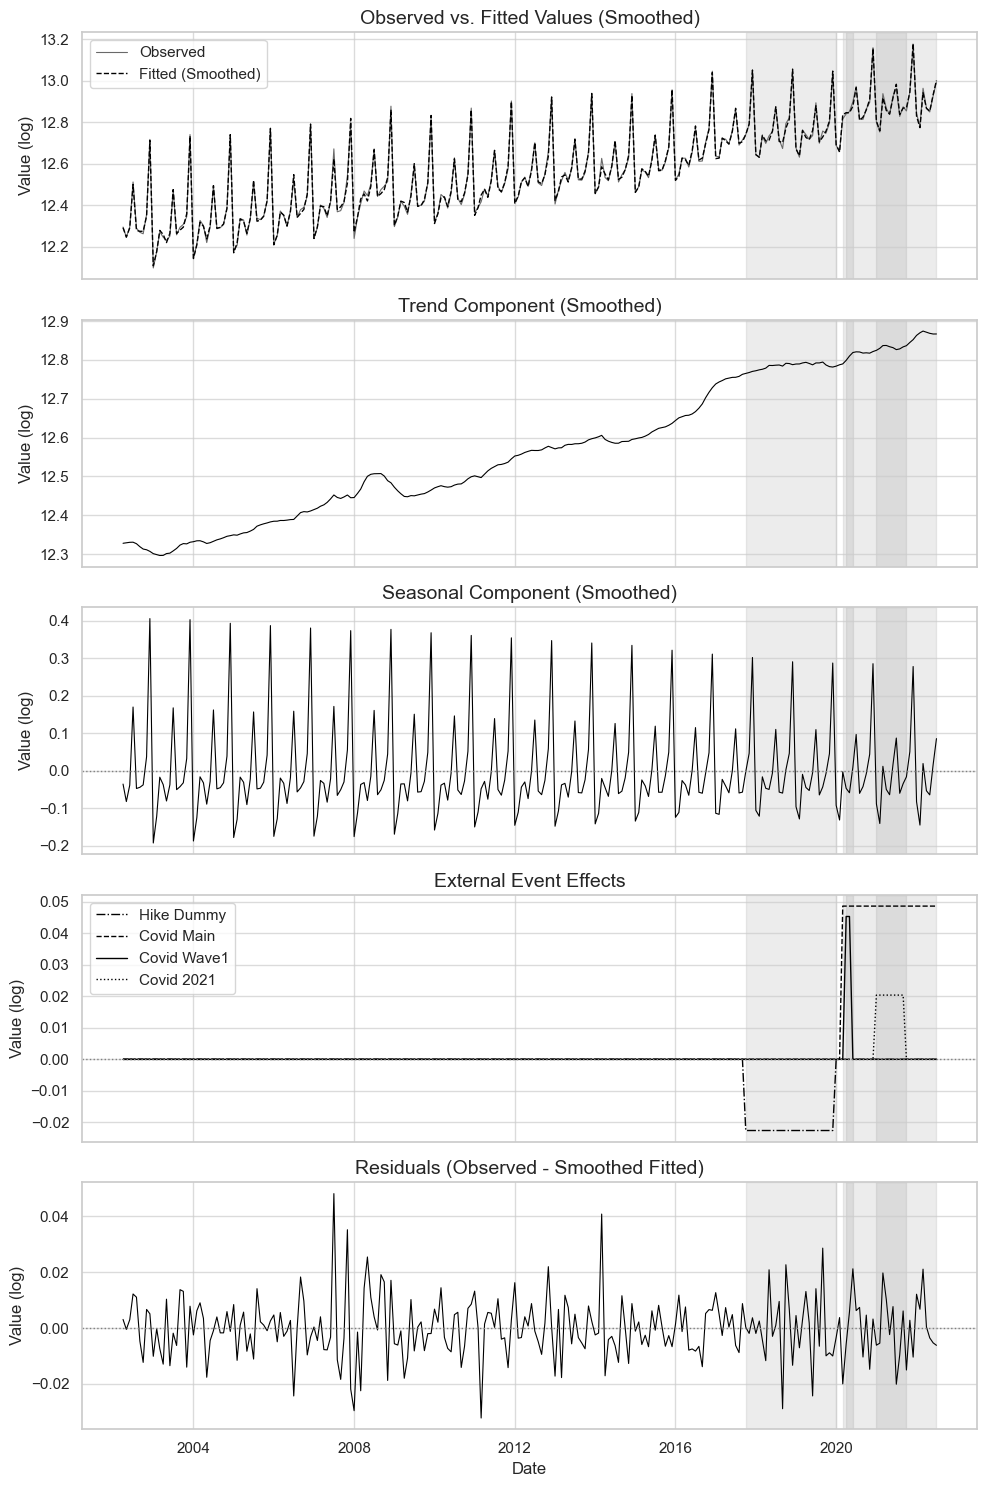

In [7]:
from src.visualization import ThesisVisualizer
# from src.color_visualization import ColorThesisVisualizer

viz = ThesisVisualizer(
    result=result, 
    df=df, 
    exog_names=exog_names, 
    event_config=custom_events
)

viz.plot_reproduction()